# Climate Policy Archetypes - Consolidated Notebook with all my previous notebooks that now work with my new final datasets

runs three experiments:

1. **Snapshot Clustering** — What archetypes exist when we treat each country as a single averaged data point?
2. **Feature Set Comparison** — Do the clusters change when we remove economic indicators? (Finding over/underperformers)
3. **Temporal Trajectories** — How have countries *moved* through archetype space over time?

---
**Prerequisites:** Run `collecting.py` and `cleaning.py` first to generate:
- `data/processed/avg_cleaned_feature_matrix.csv`
- `data/processed/temporal_cleaned_feature_matrix.csv`

## 0. Setup

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import random, os, warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    TORCH_AVAILABLE = True
    print("PyTorch available:", torch.__version__)
except ImportError:
    TORCH_AVAILABLE = False
    print("[WARNING] PyTorch not found — autoencoder sections will be skipped.")

# ── Reproducibility ──────────────────────────────────────────────────────────
# Setting seeds so that results are consistent across runs so I can test if changes to the code are improving things or not
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if TORCH_AVAILABLE:
    torch.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

os.makedirs('outputs', exist_ok=True)
print("Setup complete.")

PyTorch available: 2.10.0
Setup complete.


In [122]:
# ── Tweaks for experimentation ───────────────────────────────────────

K = 6                    # Number of clusters
AE_EPOCHS = 500          # Autoencoder training epochs
AE_LR     = 0.005        # Autoencoder learning rate

# Paths
PATH_AVG      = '../data/processed/avg_cleaned_feature_matrix.csv'
PATH_TEMPORAL = '../data/processed/temporal_cleaned_feature_matrix.csv'

# Economic columns — used when running policy-only experiments
ECON_COLS = ['log_gdp_pc', 'nd_gain_score']

# ── Load data ─────────────────────────────────────────────────────────────────
df_avg = pd.read_csv(PATH_AVG)
print(f"Averaged dataset:  {df_avg.shape[0]} countries × {df_avg.shape[1]} columns")

df_temporal = pd.read_csv(PATH_TEMPORAL)
print(f"Temporal dataset:  {df_temporal.shape[0]} rows × {df_temporal.shape[1]} columns")

# Separate identifiers from features for each dataset
AVG_ID_COLS  = ['country_code', 'Name']
TEMP_ID_COLS = ['country_code', 'Name', 'year']

ids_avg  = df_avg[AVG_ID_COLS]
X_avg    = df_avg.drop(columns=AVG_ID_COLS)

ids_temp = df_temporal[TEMP_ID_COLS]
X_temp   = df_temporal.drop(columns=TEMP_ID_COLS)

print(f"\nFeature matrix (averaged):  {X_avg.shape}")
print(f"Feature matrix (temporal):  {X_temp.shape}")

Averaged dataset:  49 countries × 22 columns
Temporal dataset:  1029 rows × 23 columns

Feature matrix (averaged):  (49, 20)
Feature matrix (temporal):  (1029, 20)


---
## Part 1 — Snapshot Clustering (Averaged Data)

Each country is a single point representing its average across all years.
Comparing the three methods: **KMeans**, **Hierarchical**, and **DBSCAN**.

### 1a. KMeans — Finding the right K

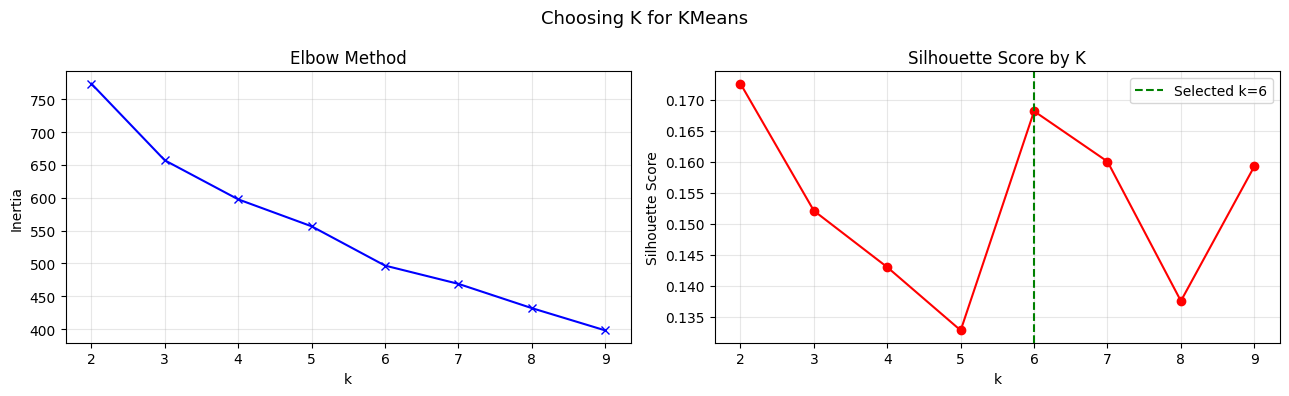

Best silhouette: k=2, score=0.1726


In [50]:
# Elbow plot 
inertia, sil_scores = [], []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_avg)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_avg, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(K_range, inertia, 'bx-')
ax1.set_title('Elbow Method')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia')
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, sil_scores, 'ro-')
ax2.set_title('Silhouette Score by K')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette Score')
ax2.axvline(x=K, color='green', linestyle='--', label=f'Selected k={K}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Choosing K for KMeans', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/elbow.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Best silhouette: k={list(K_range)[np.argmax(sil_scores)]}, score={max(sil_scores):.4f}")

In [51]:
# Run KMeans with chosen K
km = KMeans(n_clusters=K, random_state=SEED, n_init=10)
km_labels = km.fit_predict(X_avg)
km_score  = silhouette_score(X_avg, km_labels)

df_avg['km_cluster'] = km_labels

print(f"KMeans Silhouette Score: {km_score:.4f}\n")
for i in range(K):
    countries = df_avg[df_avg['km_cluster'] == i]['Name'].sort_values().tolist()
    print(f"  Archetype {i} ({len(countries)}): {', '.join(countries)}")

KMeans Silhouette Score: 0.1681

  Archetype 0 (14): Austria, Belgium, France, Germany, Greece, Italy, Latvia, Lithuania, Netherlands, Portugal, Slovakia, Spain, Switzerland, United Kingdom
  Archetype 1 (7): Brazil, India, Indonesia, Peru, Philippines, Turkey, Viet Nam
  Archetype 2 (7): Canada, Finland, Iceland, Ireland, Luxembourg, Norway, Sweden
  Archetype 3 (2): Denmark, New Zealand
  Archetype 4 (7): Argentina, Chile, Colombia, Japan, Mexico, Slovenia, South Africa
  Archetype 5 (12): Australia, China, Czech Republic, Estonia, Hungary, Israel, Korea, Republic of, Poland, Russian Federation, Saudi Arabia, Singapore, United States


In [52]:
# Run the same KMeand but also with kmeans++ initialization to see if it improves the results
km_pp = KMeans(n_clusters=K, random_state=SEED, n_init=10, init='k-means++')
km_pp_labels = km_pp.fit_predict(X_avg)
km_pp_score  = silhouette_score(X_avg, km_pp_labels)    
print(f"\nKMeans++ Silhouette Score: {km_pp_score:.4f}\n")
for i in range(K):
    countries = df_avg[km_pp_labels == i]['Name'].sort_values().tolist()
    print(f"  Archetype {i} ({len(countries)}): {', '.join(countries)}")    

    


KMeans++ Silhouette Score: 0.1681

  Archetype 0 (14): Austria, Belgium, France, Germany, Greece, Italy, Latvia, Lithuania, Netherlands, Portugal, Slovakia, Spain, Switzerland, United Kingdom
  Archetype 1 (7): Brazil, India, Indonesia, Peru, Philippines, Turkey, Viet Nam
  Archetype 2 (7): Canada, Finland, Iceland, Ireland, Luxembourg, Norway, Sweden
  Archetype 3 (2): Denmark, New Zealand
  Archetype 4 (7): Argentina, Chile, Colombia, Japan, Mexico, Slovenia, South Africa
  Archetype 5 (12): Australia, China, Czech Republic, Estonia, Hungary, Israel, Korea, Republic of, Poland, Russian Federation, Saudi Arabia, Singapore, United States


### 1b. Hierarchical Clustering

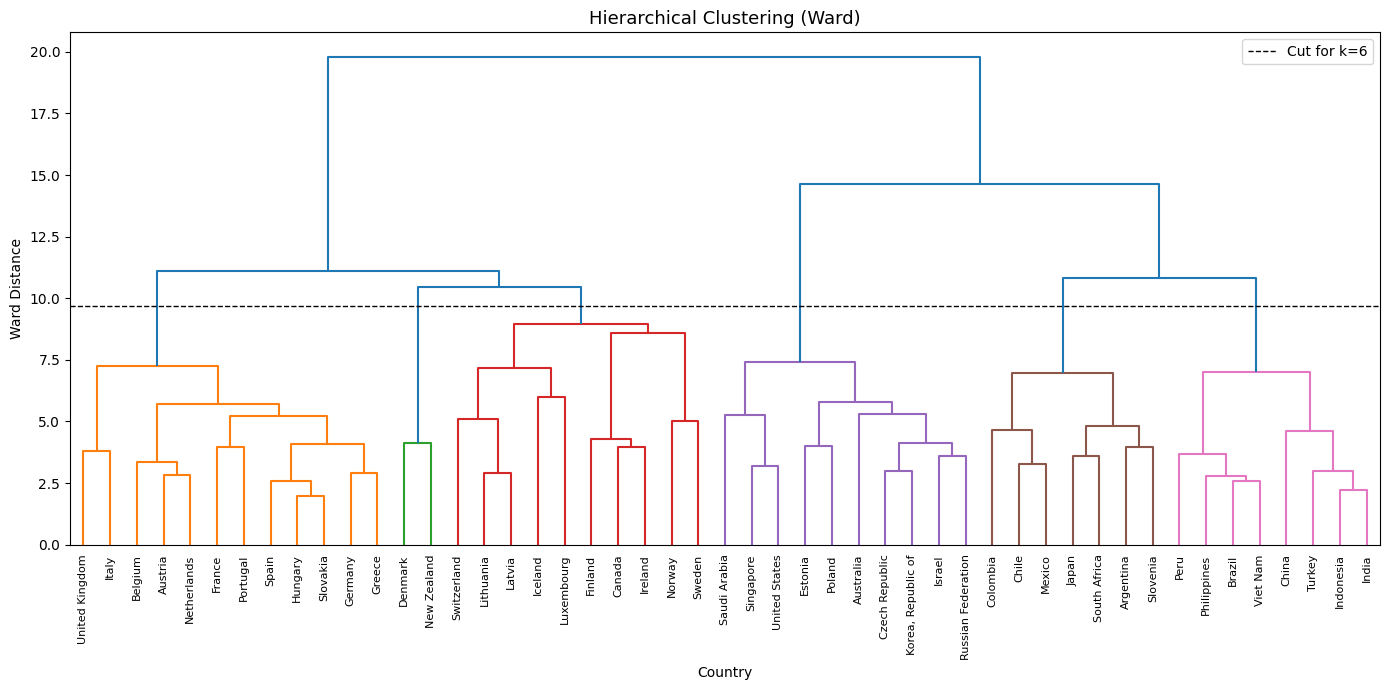

In [91]:
linked = linkage(X_avg, method='ward')

# change k just for this block
hier_k = K

# Find the cut height for k=6
cut_height = (linked[-hier_k, 2] + linked[-(hier_k-1), 2]) / 2

plt.figure(figsize=(14, 7))
dendrogram(
    linked,
    labels=ids_avg['Name'].values,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=cut_height,
)
plt.axhline(y=cut_height, color='black', linestyle='--', linewidth=1, label=f'Cut for k={hier_k}')
plt.legend()
plt.title('Hierarchical Clustering (Ward)', fontsize=13)
plt.xlabel('Country')
plt.ylabel('Ward Distance')
plt.tight_layout()
plt.savefig('outputs/dendrogram.png', dpi=120, bbox_inches='tight')
plt.show()

In [92]:
hier_labels = fcluster(linked, K, criterion='maxclust')
hier_score  = silhouette_score(X_avg, hier_labels)

df_avg['hier_cluster'] = hier_labels

print(f"Hierarchical Silhouette Score: {hier_score:.4f}\n")
for i in sorted(df_avg['hier_cluster'].unique()):
    countries = df_avg[df_avg['hier_cluster'] == i]['Name'].sort_values().tolist()
    print(f"  Cluster {i} ({len(countries)}): {', '.join(countries)}")

Hierarchical Silhouette Score: 0.1606

  Cluster 1 (12): Austria, Belgium, France, Germany, Greece, Hungary, Italy, Netherlands, Portugal, Slovakia, Spain, United Kingdom
  Cluster 2 (2): Denmark, New Zealand
  Cluster 3 (10): Canada, Finland, Iceland, Ireland, Latvia, Lithuania, Luxembourg, Norway, Sweden, Switzerland
  Cluster 4 (10): Australia, Czech Republic, Estonia, Israel, Korea, Republic of, Poland, Russian Federation, Saudi Arabia, Singapore, United States
  Cluster 5 (7): Argentina, Chile, Colombia, Japan, Mexico, Slovenia, South Africa
  Cluster 6 (8): Brazil, China, India, Indonesia, Peru, Philippines, Turkey, Viet Nam


### 1c. Cluster Fingerprints

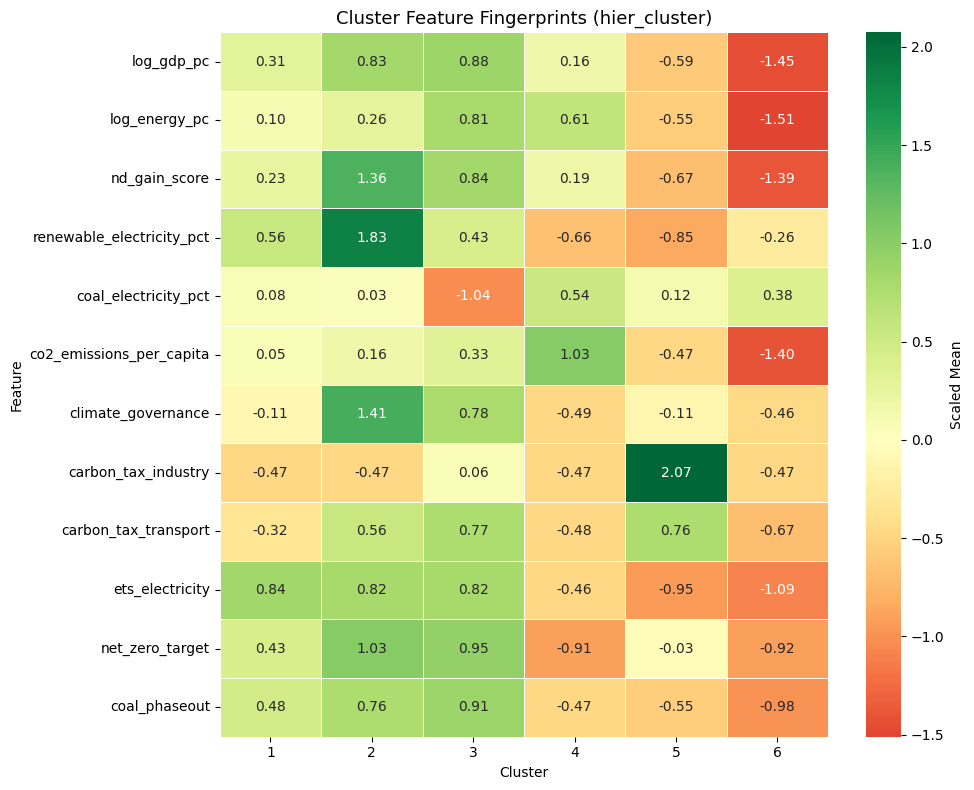

In [94]:
# Choose which method to profile in the heatmap below
PROFILE_METHOD = 'hier_cluster'

# Select a readable subset of features for the heatmap
PROFILE_COLS = [
    'log_gdp_pc', 'log_energy_pc', 'nd_gain_score',
    'renewable_electricity_pct', 'coal_electricity_pct',
    'co2_emissions_per_capita',
    'climate_governance',
    'carbon_tax_electricity', 'carbon_tax_industry', 'carbon_tax_transport',
    'ets_electricity', 'ets_industry',
    'net_zero_target', 'ndc',
    'rdd_renewables', 'fossil_fuel_subsidy_reform',
    'coal_phaseout', 'ice_vehicle_phaseout'
]
# Filter to only columns that actually exist in the dataframe
profile_cols = [c for c in PROFILE_COLS if c in df_avg.columns]

profile = df_avg.groupby(PROFILE_METHOD)[profile_cols].mean()

plt.figure(figsize=(10, 8))
sns.heatmap(
    profile.T,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.4,
    cbar_kws={'label': 'Scaled Mean'}
)
plt.title(f'Cluster Feature Fingerprints ({PROFILE_METHOD})', fontsize=13)
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('outputs/cluster_fingerprints.png', dpi=120, bbox_inches='tight')
plt.show()

### 1d. DBSCAN — Outlier Detection

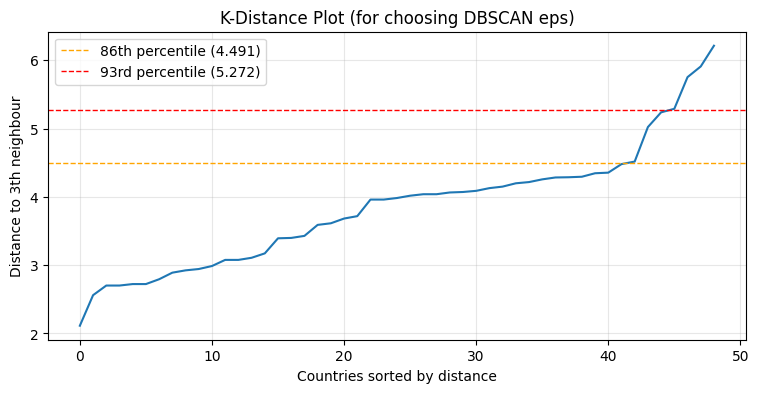

In [107]:
# k-distance plot to estimate eps
MIN_SAMPLES = 3
neigh = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neigh.fit(X_avg)
distances, _ = neigh.kneighbors(X_avg)
kth_distances = np.sort(distances[:, MIN_SAMPLES - 1])

p80 = np.percentile(kth_distances, 86)
p90 = np.percentile(kth_distances, 93)

plt.figure(figsize=(9, 4))
plt.plot(kth_distances)
plt.axhline(y=p80, color='orange', linestyle='--', linewidth=1, label=f'86th percentile ({p80:.3f})')
plt.axhline(y=p90, color='red', linestyle='--', linewidth=1, label=f'93rd percentile ({p90:.3f})')
plt.title('K-Distance Plot (for choosing DBSCAN eps)')
plt.ylabel(f'Distance to {MIN_SAMPLES}th neighbour')
plt.xlabel('Countries sorted by distance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('outputs/dbscan_kdistance.png', dpi=120, bbox_inches='tight')
plt.show()

In [115]:
# ── Adjust eps based on the plot above ───────────────────────────────────────
DBSCAN_EPS = np.percentile(kth_distances, 86)

db = DBSCAN(eps=DBSCAN_EPS, min_samples=MIN_SAMPLES)
db_labels = db.fit_predict(X_avg)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
outliers   = ids_avg['Name'][db_labels == -1].tolist()

print(f"DBSCAN found {n_clusters} cluster(s) with eps={DBSCAN_EPS:.3f}")
print(f"\nOutliers ({len(outliers)}) — countries so distinct they don't fit any cluster:")
for o in sorted(outliers):
    print(f"  • {o}")

# For each cluster, list the member countries
clusters = {}
for label in set(db_labels):
    if label == -1:
        continue  # Skip outliers
    cluster_countries = ids_avg['Name'][db_labels == label].sort_values().tolist()
    clusters[label] = cluster_countries
    print(f"\nCluster {label} ({len(cluster_countries)} countries):")
    for country in cluster_countries:
        print(f"  • {country}")


DBSCAN found 1 cluster(s) with eps=4.491

Outliers (5) — countries so distinct they don't fit any cluster:
  • Denmark
  • Luxembourg
  • New Zealand
  • Norway
  • Sweden

Cluster 0 (44 countries):
  • Argentina
  • Australia
  • Austria
  • Belgium
  • Brazil
  • Canada
  • Chile
  • China
  • Colombia
  • Czech Republic
  • Estonia
  • Finland
  • France
  • Germany
  • Greece
  • Hungary
  • Iceland
  • India
  • Indonesia
  • Ireland
  • Israel
  • Italy
  • Japan
  • Korea, Republic of
  • Latvia
  • Lithuania
  • Mexico
  • Netherlands
  • Peru
  • Philippines
  • Poland
  • Portugal
  • Russian Federation
  • Saudi Arabia
  • Singapore
  • Slovakia
  • Slovenia
  • South Africa
  • Spain
  • Switzerland
  • Turkey
  • United Kingdom
  • United States
  • Viet Nam


### 1e. Stability Check — How reliable are the KMeans clusters?

Runs KMeans 50 times with different seeds and checks how often pairs of countries end up together.
High co-occurrence (>90%) = stable pairing 

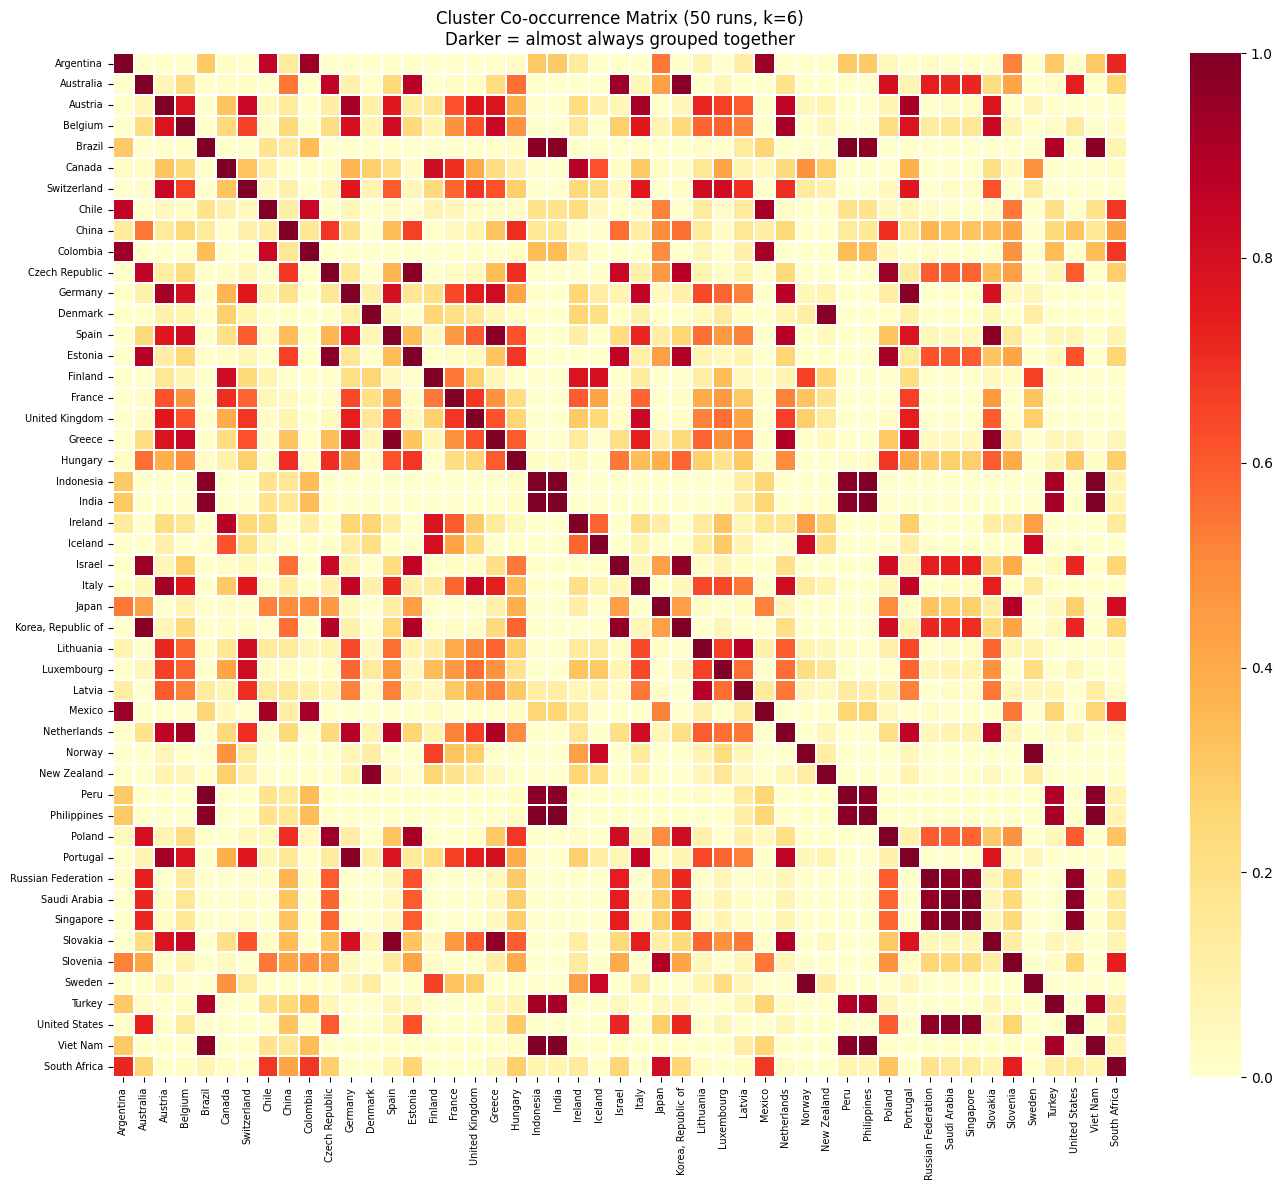


Most stable pairs (co-occurrence > 90%):
  Argentina                 ↔  Colombia                  (94%)
  Argentina                 ↔  Mexico                    (94%)
  Australia                 ↔  Israel                    (94%)
  Australia                 ↔  Korea, Republic of        (98%)
  Austria                   ↔  Germany                   (92%)
  Austria                   ↔  Italy                     (92%)
  Austria                   ↔  Portugal                  (92%)
  Belgium                   ↔  Netherlands               (92%)
  Brazil                    ↔  Indonesia                 (98%)
  Brazil                    ↔  India                     (98%)
  Brazil                    ↔  Peru                      (100%)
  Brazil                    ↔  Philippines               (98%)
  Brazil                    ↔  Viet Nam                  (98%)
  Chile                     ↔  Mexico                    (92%)
  Colombia                  ↔  Mexico                    (92%)
  Czech Repu

In [131]:
N_RUNS = 50
country_names = ids_avg['Name'].values
n = len(country_names)
co_occurrence = np.zeros((n, n))

for i in range(N_RUNS):
    km_s = KMeans(n_clusters=K, random_state=i, n_init=5)
    labels_s = km_s.fit_predict(X_avg)
    for a in range(n):
        for b in range(n):
            if labels_s[a] == labels_s[b]:
                co_occurrence[a, b] += 1

co_occurrence /= N_RUNS

plt.figure(figsize=(14, 12))
sns.heatmap(
    co_occurrence,
    xticklabels=country_names,
    yticklabels=country_names,
    cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.2
)
plt.title(f'Cluster Co-occurrence Matrix ({N_RUNS} runs, k={K})\nDarker = almost always grouped together', fontsize=12)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7, rotation=0)
plt.tight_layout()
plt.savefig('outputs/stability_cooccurrence.png', dpi=120, bbox_inches='tight')
plt.show()

# Print most stable pairs
THRESHOLD = 0.90
print(f"\nMost stable pairs (co-occurrence > {THRESHOLD:.0%}):")
printed = set()
for a in range(n):
    for b in range(a + 1, n):
        if co_occurrence[a, b] > THRESHOLD:
            pair = (country_names[a], country_names[b])
            if pair not in printed:
                print(f"  {country_names[a]:<25} ↔  {country_names[b]:<25} ({co_occurrence[a, b]:.0%})")
                printed.add(pair)

# Print most unstable pairs
THRESHOLD = 0.10
print(f"\nMost unstable pairs (co-occurrence < {THRESHOLD:.0%}):")
printed = set()
for a in range(n):
    for b in range(a + 1, n):
        if co_occurrence[a, b] < THRESHOLD:
            pair = (country_names[a], country_names[b])
            if pair not in printed:
                print(f"  {country_names[a]:<25} ↔  {country_names[b]:<25} ({co_occurrence[a, b]:.0%})")
                printed.add(pair)


---
## Part 2 — Feature Set Comparison: Capacity vs. Effort

Running the same clustering with and without economic indicators.
Interested in Countries whose cluster changes 

In [132]:
# Build policy-only feature set
econ_present   = [c for c in ECON_COLS if c in X_avg.columns]
X_policy_only  = X_avg.drop(columns=econ_present)

print(f"Full feature set:        {X_avg.shape[1]} features")
print(f"Policy-only feature set: {X_policy_only.shape[1]} features")
print(f"Dropped: {econ_present}")

Full feature set:        20 features
Policy-only feature set: 18 features
Dropped: ['log_gdp_pc', 'nd_gain_score']


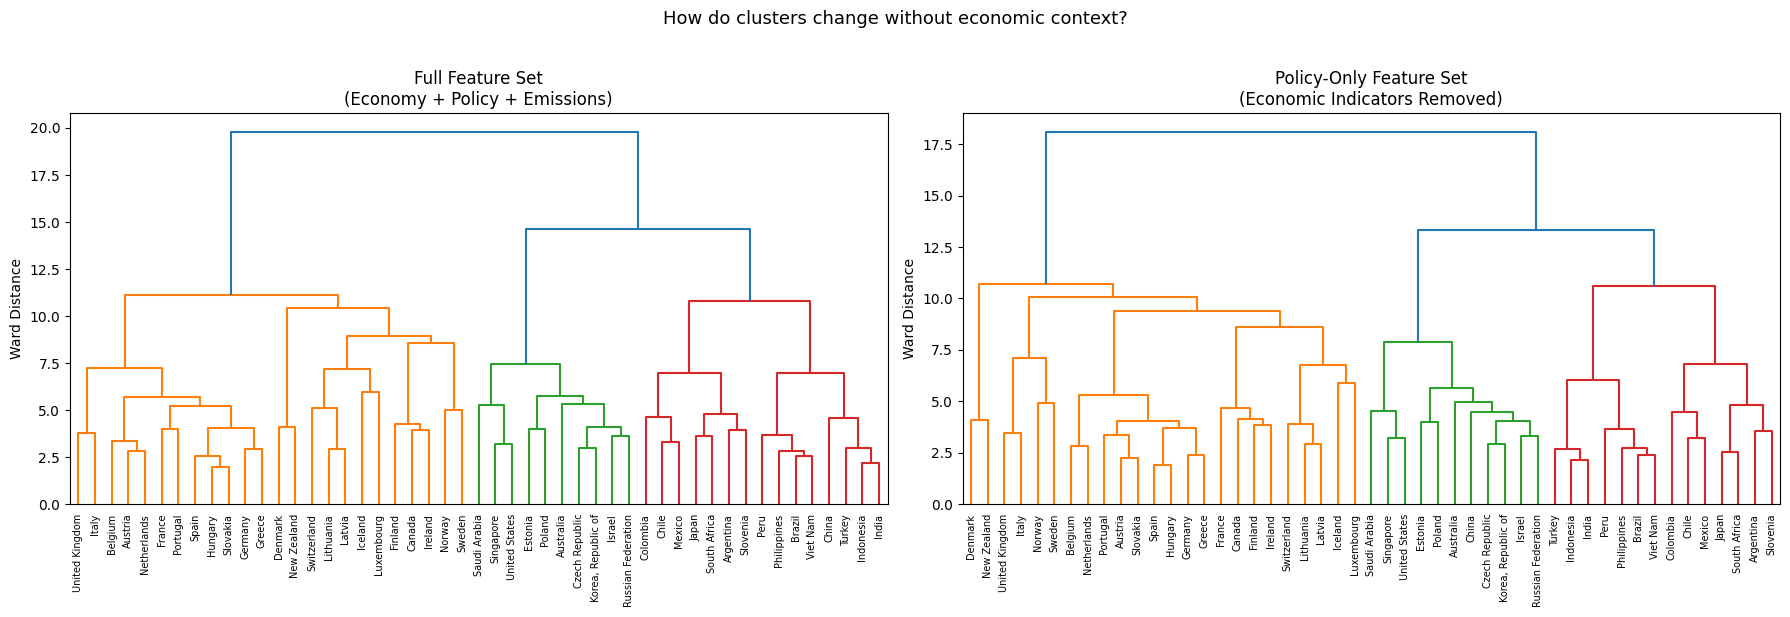

In [133]:
# Run hierarchical on both
linked_full   = linkage(X_avg, method='ward')
linked_policy = linkage(X_policy_only, method='ward')

labels_full   = fcluster(linked_full,   K, criterion='maxclust')
labels_policy = fcluster(linked_policy, K, criterion='maxclust')

# Side-by-side dendrograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

dendrogram(linked_full,   labels=ids_avg['Name'].values, leaf_rotation=90, leaf_font_size=7, ax=ax1)
ax1.set_title('Full Feature Set\n(Economy + Policy + Emissions)')
ax1.set_ylabel('Ward Distance')

dendrogram(linked_policy, labels=ids_avg['Name'].values, leaf_rotation=90, leaf_font_size=7, ax=ax2)
ax2.set_title('Policy-Only Feature Set\n(Economic Indicators Removed)')
ax2.set_ylabel('Ward Distance')

plt.suptitle('How do clusters change without economic context?', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('outputs/comparison_dendrograms.png', dpi=120, bbox_inches='tight')
plt.show()

In [134]:
# Find countries that switch clusters — the interesting cases
comparison = ids_avg.copy().reset_index(drop=True)
comparison['cluster_full']   = labels_full
comparison['cluster_policy'] = labels_policy
comparison['switched']       = comparison['cluster_full'] != comparison['cluster_policy']

switchers     = comparison[comparison['switched']]
non_switchers = comparison[~comparison['switched']]

print(f"Stable countries ({len(non_switchers)}):")
print(f"  {', '.join(sorted(non_switchers['Name'].tolist()))}\n")

print(f"Countries whose cluster changes when economic indicators are removed ({len(switchers)}):")
print(f"{'Country':<30} {'Full':<10} {'Policy-only':<10}")
print("-" * 50)
for _, row in switchers.sort_values('Name').iterrows():
    print(f"{row['Name']:<30} {row['cluster_full']:<10} {row['cluster_policy']:<10}")

comparison.to_csv('outputs/overperformer_analysis.csv', index=False)
print("\nSaved to outputs/overperformer_analysis.csv")

Stable countries (18):
  Australia, Canada, Czech Republic, Estonia, Finland, Iceland, Ireland, Israel, Korea, Republic of, Latvia, Lithuania, Luxembourg, Poland, Russian Federation, Saudi Arabia, Singapore, Switzerland, United States

Countries whose cluster changes when economic indicators are removed (31):
Country                        Full       Policy-only
--------------------------------------------------
Argentina                      5          6         
Austria                        1          3         
Belgium                        1          3         
Brazil                         6          5         
Chile                          5          6         
China                          6          4         
Colombia                       5          6         
Denmark                        2          1         
France                         1          3         
Germany                        1          3         
Greece                         1          3         
H

---
## Part 3 — Autoencoder Experiments (averaged data)

Compressing the data to 3D using a neural autoencoder, then clustering in that latent space.
The higher silhouette score suggests the AE is finding non-linear structure that PCA/hierarchical miss.

  Epoch [100/500] Loss: 0.4936
  Epoch [200/500] Loss: 0.2694
  Early stopping at epoch 287, best loss: 0.2001


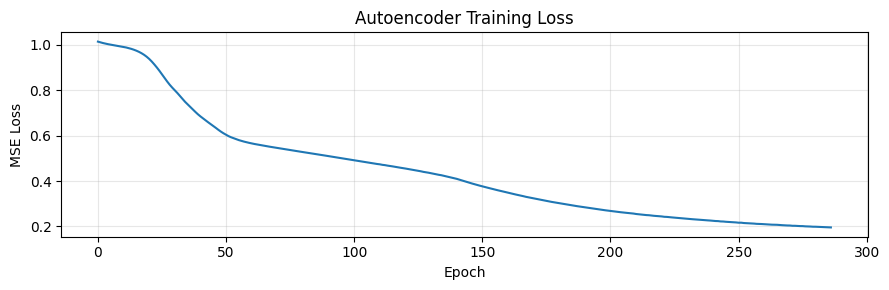

In [124]:
if not TORCH_AVAILABLE:
    print("Skipping... PyTorch not available.")
else:
    class ClimateAE(nn.Module):
        def __init__(self, input_dim):
            super().__init__()

            # Encoding down 3 layers to get compressed latent space
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, 16), nn.ReLU(),
                nn.Linear(16, 8),        nn.ReLU(),
                nn.Linear(8, 3)
            )

            # Decoding back up to original dimension
            self.decoder = nn.Sequential(
                nn.Linear(3, 8),          nn.ReLU(),
                nn.Linear(8, 16),         nn.ReLU(),
                nn.Linear(16, input_dim)
            )
        # Defining what we get back: both the latent representation and the reconstructed output
        # Cluster on the latent space but compute loss with the reconstructed output
        def forward(self, x):
            latent  = self.encoder(x)
            decoded = self.decoder(latent)
            return latent, decoded

    torch.manual_seed(SEED)
    # Converting the feature matrix to a PyTorch tensor for training 
    X_tensor   = torch.FloatTensor(X_avg.values)
    input_dim  = X_avg.shape[1]
    model      = ClimateAE(input_dim)

    # Using Adam optimizer and MSE loss for reconstruction
    optimizer  = optim.Adam(model.parameters(), lr=AE_LR)
    # mean squared error between reconstruction and original input
    criterion  = nn.MSELoss()

    # Save column order so we can use it for the counterfactual section
    FEATURE_COLS = list(X_avg.columns)

    losses = []
    best_loss = float('inf')
    patience = 10
    epochs_no_improve = 0
    min_delta = 0.005

    for epoch in range(AE_EPOCHS):
        model.train()
        latent, decoded = model(X_tensor)
        loss = criterion(decoded, X_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
        # Early stopping check
        if best_loss - loss.item() > min_delta:
            best_loss = loss.item()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        if epochs_no_improve >= patience:
            print(f"  Early stopping at epoch {epoch+1}, best loss: {best_loss:.4f}")
            break
        
        if (epoch + 1) % 100 == 0:
            print(f"  Epoch [{epoch+1}/{AE_EPOCHS}] Loss: {loss.item():.4f}")

    plt.figure(figsize=(9, 3))
    plt.plot(losses)
    plt.title('Autoencoder Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/ae_loss.png', dpi=120, bbox_inches='tight')
    plt.show()

In [125]:
if not TORCH_AVAILABLE:
    print("Skipping.")
else:
    model.eval()
    with torch.no_grad():
        X_latent, _ = model(X_tensor)
        X_latent = X_latent.numpy()

    # KMeans in latent space
    km_ae     = KMeans(n_clusters=K, random_state=SEED, n_init=10)
    ae_labels = km_ae.fit_predict(X_latent)
    ae_score  = silhouette_score(X_latent, ae_labels)

    df_avg['ae_cluster'] = ae_labels

    print(f"AE+KMeans Silhouette Score: {ae_score:.4f}\n")
    for i in range(K):
        countries = df_avg[df_avg['ae_cluster'] == i]['Name'].sort_values().tolist()
        print(f"  Archetype {i} ({len(countries)}): {', '.join(countries)}")

    # 3D interactive plot
    df_viz = pd.DataFrame(X_latent, columns=['Latent_1', 'Latent_2', 'Latent_3'])
    df_viz['Country'] = ids_avg['Name'].values
    df_viz['Cluster'] = ae_labels.astype(str)

    fig = px.scatter_3d(
        df_viz, x='Latent_1', y='Latent_2', z='Latent_3',
        color='Cluster', hover_name='Country',
        title=f'AE Latent Space — Silhouette: {ae_score:.3f}',
        template='plotly_dark', opacity=0.85
    )
    fig.write_html('outputs/ae_latent_3d.html')
    fig.show()
    print("\nInteractive 3D plot saved to outputs/ae_latent_3d.html")

AE+KMeans Silhouette Score: 0.3705

  Archetype 0 (10): China, Greece, Hungary, India, Japan, Slovakia, Slovenia, South Africa, Spain, Turkey
  Archetype 1 (6): Denmark, Finland, Iceland, New Zealand, Norway, Sweden
  Archetype 2 (9): Australia, Belgium, Czech Republic, Estonia, Israel, Korea, Republic of, Luxembourg, Netherlands, Poland
  Archetype 3 (9): Argentina, Brazil, Chile, Colombia, Indonesia, Mexico, Peru, Philippines, Viet Nam
  Archetype 4 (4): Russian Federation, Saudi Arabia, Singapore, United States
  Archetype 5 (11): Austria, Canada, France, Germany, Ireland, Italy, Latvia, Lithuania, Portugal, Switzerland, United Kingdom



Interactive 3D plot saved to outputs/ae_latent_3d.html


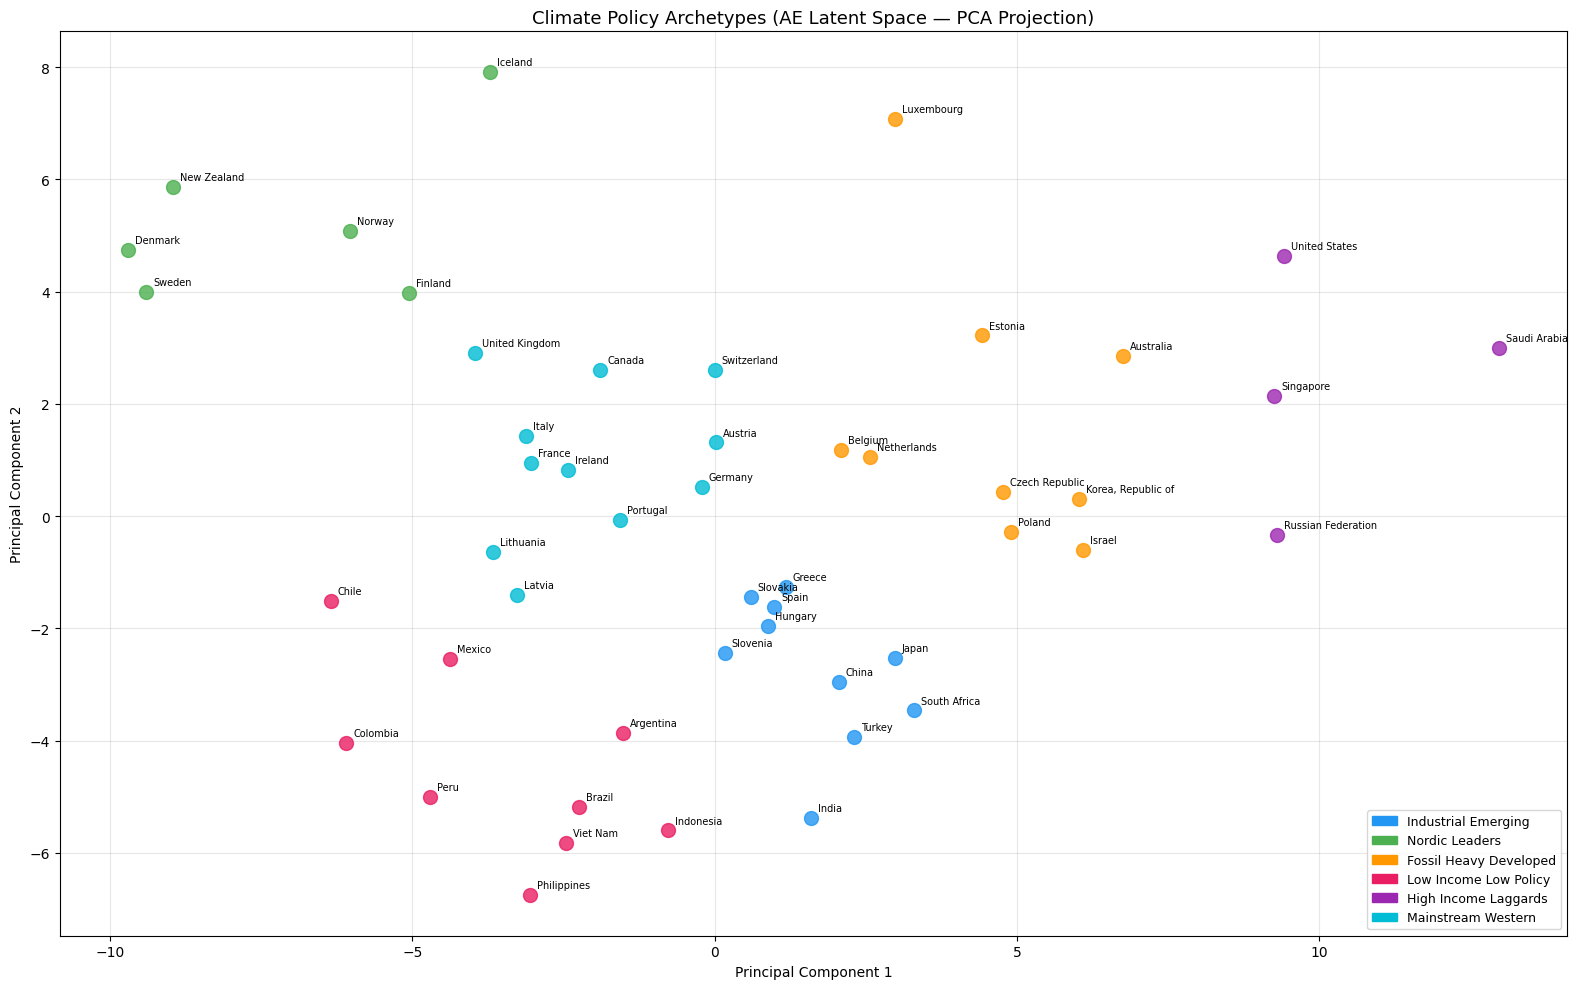

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

archetype_names = {
    0: 'Industrial Emerging',
    1: 'Nordic Leaders',
    2: 'Fossil Heavy Developed',
    3: 'Low Income Low Policy',
    4: 'High Income Laggards',
    5: 'Mainstream Western'
}

CLUSTER_COLOURS_MPL = {
    0: '#2196F3',   # blue
    1: '#4CAF50',   # green
    2: '#FF9800',   # orange
    3: '#E91E63',   # pink/red
    4: '#9C27B0',   # purple
    5: '#00BCD4',   # cyan
}

# Project latent space to 2D using PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_latent)

fig, ax = plt.subplots(figsize=(16, 10))

for cluster_id in range(K):
    mask = ae_labels == cluster_id
    ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=CLUSTER_COLOURS_MPL[cluster_id],
        s=100, alpha=0.8, zorder=2
    )
    for idx in np.where(mask)[0]:
        ax.annotate(
            ids_avg['Name'].values[idx],
            (X_2d[idx, 0], X_2d[idx, 1]),
            fontsize=7,
            xytext=(5, 5),
            textcoords='offset points'
        )

# Legend
patches = [
    mpatches.Patch(color=CLUSTER_COLOURS_MPL[i], label=archetype_names[i])
    for i in range(K)
]
ax.legend(handles=patches, loc='lower right', fontsize=9)

ax.set_title('Climate Policy Archetypes (AE Latent Space - PCA Projection)', fontsize=13)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/archetype_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

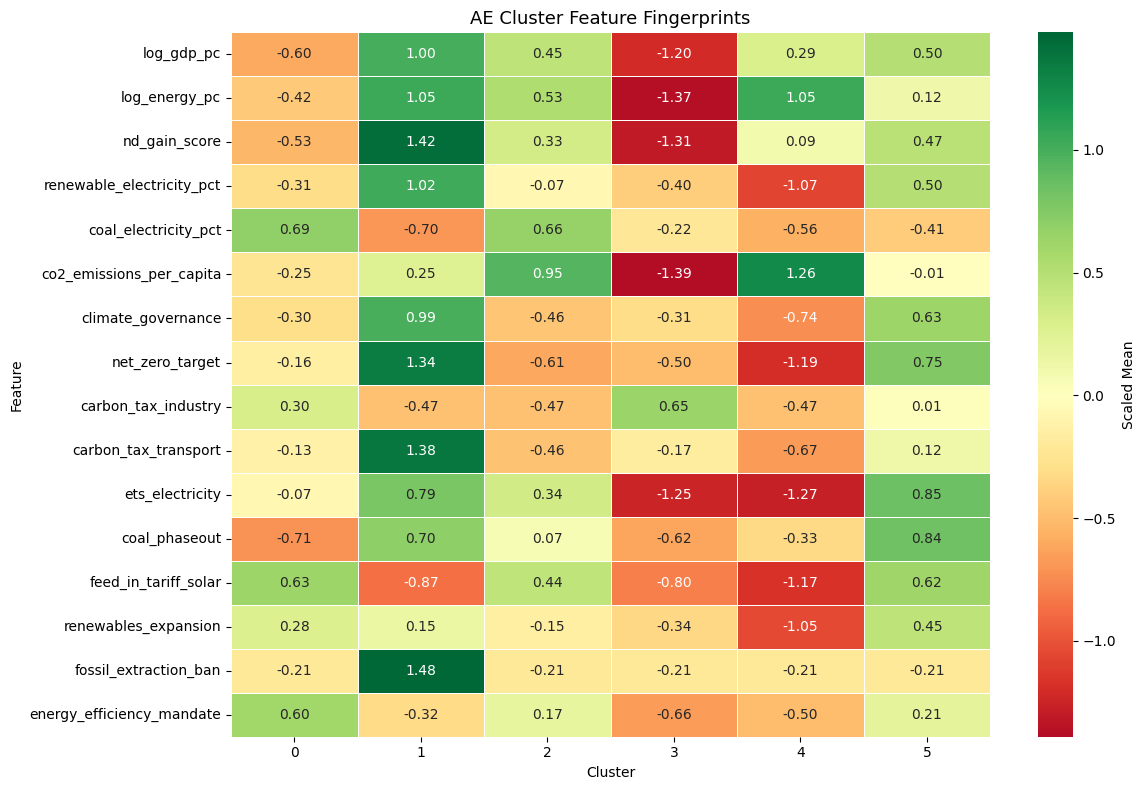


Cluster 0: China, Greece, Hungary, India, Japan, Slovakia, Slovenia, South Africa, Spain, Turkey
  GDP:        -0.60
  Net Zero:   -0.16
  Coal:       0.69
  Renewables: -0.31

Cluster 1: Denmark, Finland, Iceland, New Zealand, Norway, Sweden
  GDP:        1.00
  Net Zero:   1.34
  Coal:       -0.70
  Renewables: 1.02

Cluster 2: Australia, Belgium, Czech Republic, Estonia, Israel, Korea, Republic of, Luxembourg, Netherlands, Poland
  GDP:        0.45
  Net Zero:   -0.61
  Coal:       0.66
  Renewables: -0.07

Cluster 3: Argentina, Brazil, Chile, Colombia, Indonesia, Mexico, Peru, Philippines, Viet Nam
  GDP:        -1.20
  Net Zero:   -0.50
  Coal:       -0.22
  Renewables: -0.40

Cluster 4: Russian Federation, Saudi Arabia, Singapore, United States
  GDP:        0.29
  Net Zero:   -1.19
  Coal:       -0.56
  Renewables: -1.07

Cluster 5: Austria, Canada, France, Germany, Ireland, Italy, Latvia, Lithuania, Portugal, Switzerland, United Kingdom
  GDP:        0.50
  Net Zero:   0.75
  

In [136]:
# Add ae cluster labels to a copy with country names
df_ae_profile = df_avg.copy()

PROFILE_COLS_AE = [
    'log_gdp_pc', 'log_energy_pc', 'nd_gain_score',
    'renewable_electricity_pct', 'coal_electricity_pct',
    'co2_emissions_per_capita',
    'climate_governance', 'net_zero_target', 'ndc',
    'carbon_tax_industry', 'carbon_tax_transport',
    'ets_electricity', 'ets_industry',
    'coal_phaseout', 'ice_vehicle_phaseout',
    'feed_in_tariff_solar', 'renewables_expansion',
    'fossil_extraction_ban', 'fossil_fuel_subsidy_reform',
    'energy_efficiency_mandate'
]

profile_cols_ae = [c for c in PROFILE_COLS_AE if c in df_ae_profile.columns]
profile_ae = df_ae_profile.groupby('ae_cluster')[profile_cols_ae].mean()

plt.figure(figsize=(12, 8))
sns.heatmap(
    profile_ae.T,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.4,
    cbar_kws={'label': 'Scaled Mean'}
)
plt.title('AE Cluster Feature Fingerprints', fontsize=13)
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('outputs/ae_cluster_fingerprints.png', dpi=120, bbox_inches='tight')
plt.show()

# Also print which countries are in each cluster with their archetype label
archetype_names = {
    0: 'Archetype 0',
    1: 'Archetype 1', 
    2: 'Archetype 2',
    3: 'Archetype 3',
    4: 'Archetype 4',
    5: 'Archetype 5',
}

for i in sorted(df_ae_profile['ae_cluster'].unique()):
    countries = df_ae_profile[df_ae_profile['ae_cluster'] == i]['Name'].sort_values().tolist()
    print(f"\nCluster {i}: {', '.join(countries)}")
    print(f"  GDP:        {profile_ae.loc[i, 'log_gdp_pc']:.2f}")
    print(f"  Net Zero:   {profile_ae.loc[i, 'net_zero_target']:.2f}")
    print(f"  Coal:       {profile_ae.loc[i, 'coal_electricity_pct']:.2f}")
    print(f"  Renewables: {profile_ae.loc[i, 'renewable_electricity_pct']:.2f}")

### 3b. Counterfactual Test

Take a country's real scaled data, manually adjust specific features, and see if the model moves it to a different cluster.
This tests whether the latent space is *meaningful* 

In [126]:
if not TORCH_AVAILABLE:
    print("Skipping.")
else:
    # ── CONFIG — change this to test different countries/scenarios ────────────
    TEST_COUNTRY = 'AUS'   # ISO3 code

    # Feature tweaks (these are scaled values)
    TWEAKS = {
    'coal_electricity_pct':       -4.0,
    'renewable_electricity_pct':   4.0,
    'log_energy_pc':              -3.0,
    'carbon_tax_industry':         3.0,  
    'ets_electricity':             3.0,
    'net_zero_target':             3.0,
}
    # ─────────────────────────────────────────────────────────────────────────

    country_names_arr = ids_avg['country_code'].values
    idx = np.where(country_names_arr == TEST_COUNTRY)[0]

    if len(idx) == 0:
        print(f"Country '{TEST_COUNTRY}' not found. Available: {list(country_names_arr)}")
    else:
        idx = idx[0]
        country_display = ids_avg.iloc[idx]['Name']

        # Original
        original = X_avg.iloc[idx].copy()
        synthetic = original.copy()

        for feature, value in TWEAKS.items():
            if feature in synthetic.index:
                synthetic[feature] = value
            else:
                print(f"[Warning] Feature '{feature}' not in dataset — skipping.")

        # Enforce column order matches what the model was trained on
        synthetic = synthetic[FEATURE_COLS]
        original  = original[FEATURE_COLS]

        with torch.no_grad():
            orig_tensor  = torch.FloatTensor(original.values).unsqueeze(0)
            synth_tensor = torch.FloatTensor(synthetic.values).unsqueeze(0)
            latent_orig,  _ = model(orig_tensor)
            latent_synth, _ = model(synth_tensor)

        orig_cluster  = km_ae.predict(latent_orig.numpy())[0]
        synth_cluster = km_ae.predict(latent_synth.numpy())[0]
        distance      = torch.norm(latent_orig - latent_synth).item()

        print(f"Country: {country_display}")
        print(f"Original Cluster:   {orig_cluster}")
        print(f"Synthetic Cluster:  {synth_cluster}")
        print(f"Distance moved in latent space: {distance:.4f}")

        if orig_cluster == synth_cluster:
            print(f"\nResult: Still in Archetype {orig_cluster} — tweaks not large enough to cross a boundary.")
            print("Check distances to other cluster centres below:")
        else:
            print(f"\nResult: Moved from Archetype {orig_cluster} → Archetype {synth_cluster}!")

        print("\nDistances to each cluster centre:")
        for i, center in enumerate(km_ae.cluster_centers_):
            d = np.linalg.norm(latent_synth.numpy() - center)
            marker = " ← assigned" if i == synth_cluster else ""
            print(f"  Archetype {i}: {d:.4f}{marker}")

Country: Australia
Original Cluster:   2
Synthetic Cluster:  5
Distance moved in latent space: 11.6053

Result: Moved from Archetype 2 → Archetype 5!

Distances to each cluster centre:
  Archetype 0: 7.7800
  Archetype 1: 4.8387
  Archetype 2: 9.4012
  Archetype 3: 6.4174
  Archetype 4: 15.1327
  Archetype 5: 2.7502 ← assigned


---
## Part 4 — Temporal Trajectories

Using the full time-series dataset (country-year pairs) to see how countries have *moved* through archetype space from 2000 to the present.

In [ ]:
if not TORCH_AVAILABLE:
    print("Skipping — PyTorch required for trajectory AE.")
else:
    class ClimateTrajectoryAE(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, 16), nn.ReLU(),
                nn.Linear(16, 8),        nn.ReLU(),
                nn.Linear(8, 3)
            )
            self.decoder = nn.Sequential(
                nn.Linear(3, 8),          nn.ReLU(),
                nn.Linear(8, 16),         nn.ReLU(),
                nn.Linear(16, input_dim)
            )
        def forward(self, x):
            latent  = self.encoder(x)
            decoded = self.decoder(latent)
            return latent, decoded

    torch.manual_seed(SEED)
    X_temp_tensor = torch.FloatTensor(X_temp.values)
    traj_model    = ClimateTrajectoryAE(X_temp.shape[1])
    traj_optimizer = optim.Adam(traj_model.parameters(), lr=AE_LR)
    traj_criterion = nn.MSELoss()

    TRAJ_EPOCHS = AE_EPOCHS
    traj_losses = []
    for epoch in range(TRAJ_EPOCHS):
        latent, decoded = traj_model(X_temp_tensor)
        loss = traj_criterion(decoded, X_temp_tensor)
        traj_optimizer.zero_grad()
        loss.backward()
        traj_optimizer.step()
        traj_losses.append(loss.item())
        if (epoch + 1) % 100 == 0:
            print(f"  Epoch [{epoch+1}/{TRAJ_EPOCHS}] Loss: {loss.item():.4f}")

    print("Trajectory AE trained.")

  Epoch [100/500] Loss: 0.3295
  Epoch [200/500] Loss: 0.2082
  Epoch [300/500] Loss: 0.1643
  Epoch [400/500] Loss: 0.1441
  Epoch [500/500] Loss: 0.1312
Trajectory AE trained.


In [69]:
if not TORCH_AVAILABLE:
    print("Skipping.")
else:
    traj_model.eval()
    with torch.no_grad():
        traj_latent, _ = traj_model(X_temp_tensor)
        traj_latent = traj_latent.numpy()

    # Cluster the trajectory points
    km_traj     = KMeans(n_clusters=K, random_state=SEED, n_init=10)
    traj_labels = km_traj.fit_predict(traj_latent)
    traj_score  = silhouette_score(traj_latent, traj_labels)
    print(f"Trajectory Silhouette Score: {traj_score:.4f}")

    df_viz = pd.DataFrame(traj_latent, columns=['Dim1', 'Dim2', 'Dim3'])
    df_viz = pd.concat([ids_temp.reset_index(drop=True), df_viz], axis=1)
    df_viz['state_cluster'] = traj_labels
    df_viz = df_viz.sort_values(['country_code', 'year'])

    # 3D snake plot — each country traces its path through the latent space
    fig = px.line_3d(
        df_viz, x='Dim1', y='Dim2', z='Dim3',
        color='country_code',
        line_group='country_code',
        hover_name='Name',
        hover_data=['year'],
        title='20-Year Climate Action Trajectories (AE Latent Space)',
        template='plotly_dark'
    )
    fig.write_html('outputs/trajectories_3d.html')
    fig.show()
    print("Interactive trajectory plot saved to outputs/trajectories_3d.html")

Trajectory Silhouette Score: 0.3824


Interactive trajectory plot saved to outputs/trajectories_3d.html


In [70]:
if not TORCH_AVAILABLE:
    print("Skipping.")
else:
    # Print cluster sequence for each country — shows stability or transitions
    print("Country Climate Trajectories (cluster sequence per year)\n")
    print(f"{'Country':<25} Sequence")
    print("-" * 80)

    for country in df_viz['Name'].unique():
        seq = df_viz[df_viz['Name'] == country]['state_cluster'].tolist()
        path_str = " → ".join(map(str, seq))
        # Highlight countries that changed cluster
        changed = len(set(seq)) > 1
        marker  = " ★" if changed else ""
        print(f"{country:<25} {path_str}{marker}")

    print("\n★ = country changed cluster at least once")

Country Climate Trajectories (cluster sequence per year)

Country                   Sequence
--------------------------------------------------------------------------------
Argentina                 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 4 → 5 → 5 ★
Australia                 1 → 1 → 1 → 1 → 1 → 1 → 1 → 1 → 1 → 1 → 1 → 1 → 1 → 1 → 1 → 1 → 1 → 1 → 1 → 1 → 1
Austria                   4 → 1 → 1 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 5 → 5 → 5 → 5 ★
Belgium                   1 → 1 → 1 → 1 → 1 → 1 → 1 → 1 → 1 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 5 → 5 → 5 → 5 ★
Brazil                    2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2
Canada                    1 → 1 → 1 → 1 → 1 → 1 → 1 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 5 → 5 → 5 → 5 ★
Switzerland               0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 4 → 4 → 4 → 4 → 4 → 4 → 5 → 5 → 5 → 5 ★
Chile                     2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 

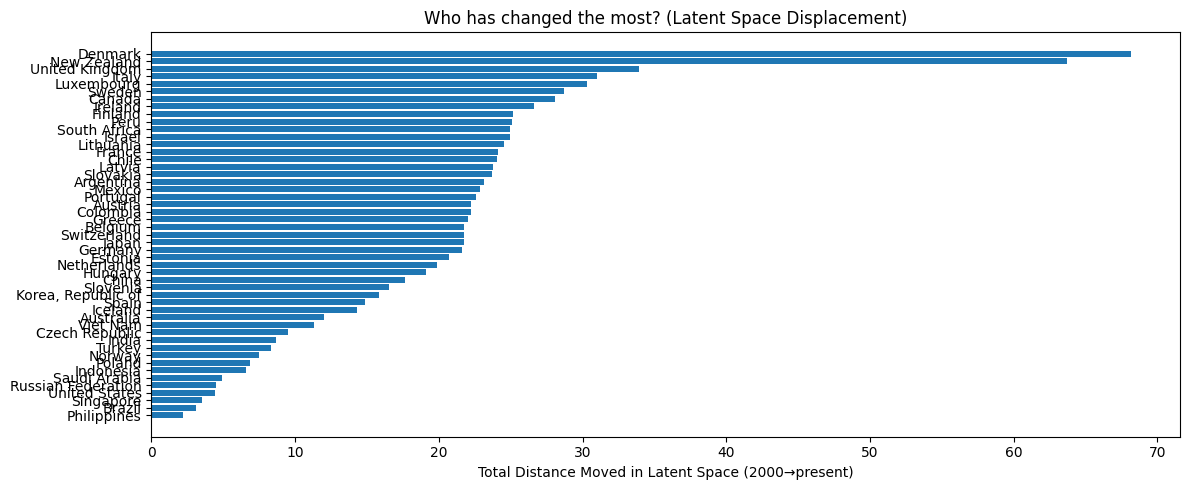

Top structural jumps detected (top 5% of year-over-year movement):
       Name  year  dist_moved  state_cluster
    Denmark  2020   43.421341              3
New Zealand  2018   41.881336              3
     Israel  2018   16.269539              5
 Luxembourg  2017   15.910885              5
     Greece  2019   14.165282              5
    Finland  2017   13.349744              5
   Portugal  2017   12.891672              5
   Slovakia  2019   12.864163              5
       Peru  2020   12.641362              5
     Sweden  2017   12.519212              5


In [71]:
if not TORCH_AVAILABLE:
    print("Skipping.")
else:
    # Distance moved year-over-year — who is accelerating?
    df_viz['dist_moved'] = (
        df_viz.groupby('country_code')
        .apply(lambda x: np.sqrt(
            x['Dim1'].diff()**2 + x['Dim2'].diff()**2 + x['Dim3'].diff()**2
        ))
        .reset_index(level=0, drop=True)
    )

    # Total distance moved per country over the full period
    total_movement = (
        df_viz.groupby('Name')['dist_moved']
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )
    total_movement.columns = ['Country', 'Total Distance Moved']

    plt.figure(figsize=(12, 5))
    plt.barh(total_movement['Country'][::-1], total_movement['Total Distance Moved'][::-1])
    plt.xlabel('Total Distance Moved in Latent Space (2000→present)')
    plt.title('Who has changed the most? (Latent Space Displacement)')
    plt.tight_layout()
    plt.savefig('outputs/total_movement.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Top structural jumps — largest single-year moves
    threshold = df_viz['dist_moved'].quantile(0.95)
    top_jumps = (
        df_viz[df_viz['dist_moved'] > threshold]
        [['Name', 'year', 'dist_moved', 'state_cluster']]
        .sort_values('dist_moved', ascending=False)
        .head(10)
    )
    print("Top structural jumps detected (top 5% of year-over-year movement):")
    print(top_jumps.to_string(index=False))

---
## Summary — Silhouette Scores Across Methods

In [128]:
scores = {
    'KMeans (full)':        km_score,
    'Hierarchical (full)':  hier_score,
}

if TORCH_AVAILABLE:
    scores['AE + KMeans (averaged)'] = ae_score
    scores['AE + KMeans (temporal)'] = traj_score

print(f"{'Method':<35} {'Silhouette Score':>16}")
print("-" * 53)
for method, score in sorted(scores.items(), key=lambda x: -x[1]):
    print(f"{method:<35} {score:>16.4f}")

Method                              Silhouette Score
-----------------------------------------------------
AE + KMeans (temporal)                        0.3824
AE + KMeans (averaged)                        0.3705
KMeans (full)                                 0.1681
Hierarchical (full)                           0.1606


---
# Testing if the model has actually learnt

In [73]:


from numpy import exp


SYNTHETIC_COUNTRIES = {
    'Perfect Nordic': {
        'renewable_electricity_pct':  2.5,
        'renewable_final_energy_pct': 2.0,
        'coal_electricity_pct':      -2.5,
        'log_gdp_pc':                 1.5,
        'log_energy_pc':             -1.0,
        'climate_governance':         2.0,
        'carbon_tax_industry':        2.5,
        'net_zero_target':            2.5,
        'ets_electricity':            2.0,
    },
    'Perfect Laggard': {
        'coal_electricity_pct':       2.5,
        'log_energy_pc':              2.0,
        'carbon_tax_industry':       -2.0,
        'net_zero_target':           -2.0,
        'ets_electricity':           -2.0,
        'climate_governance':        -2.0,
        'renewable_electricity_pct': -2.0,
    }
}
# ─────────────────────────────────────────────────────────────────────────────

# Figure out which cluster is the 'Nordic' cluster and the 'Laggard' cluster
nordic_countries  = ['Denmark', 'Norway', 'Sweden', 'Finland', 'Iceland', 'New Zealand']
laggard_countries = ['Russian Federation', 'Saudi Arabia']

# Print out the original clusters for these reference countries
print("Model Clusters:")


for i in range(K):
        countries = df_avg[df_avg['ae_cluster'] == i]['Name'].sort_values().tolist()
        print(f"  Archetype {i} ({len(countries)}): {', '.join(countries)}")

print("\n")

model.eval()
print(f"{'Country':<20}  {'Assigned Cluster':>10} ")
print("-" * 52)



for name, tweaks in SYNTHETIC_COUNTRIES.items():
    # Start from a zero vector (global mean in scaled space)
    synth = np.zeros(len(FEATURE_COLS))
    
    for feature, value in tweaks.items():
        if feature in FEATURE_COLS:
            idx = FEATURE_COLS.index(feature)
            synth[idx] = value
        else:
            print(f"  [Warning] '{feature}' not in FEATURE_COLS")
    
    synth_tensor = torch.FloatTensor(synth).unsqueeze(0)
    
    with torch.no_grad():
        latent_synth, _ = model(synth_tensor)
        assigned_cluster = km_ae.predict(latent_synth.numpy())[0]
    

    print(f"{name:<20}  {str(assigned_cluster):>10} ")


    print("\n")
    # Also print distances to all cluster centres
    print(f"  Distances to cluster centres:")
    for i, center in enumerate(km_ae.cluster_centers_):
        d = np.linalg.norm(latent_synth.numpy() - center)
        marker = ' ← assigned' if i == assigned_cluster else ''
        print(f"    Cluster {i}: {d:.3f}{marker}")
    print()


Model Clusters:
  Archetype 0 (8): Brazil, Colombia, India, Indonesia, Peru, Philippines, Turkey, Viet Nam
  Archetype 1 (10): Australia, Belgium, Estonia, Israel, Korea, Republic of, Poland, Russian Federation, Saudi Arabia, Singapore, United States
  Archetype 2 (13): Austria, China, Czech Republic, Germany, Greece, Hungary, Italy, Lithuania, Netherlands, Portugal, Slovakia, Spain, Switzerland
  Archetype 3 (2): Denmark, New Zealand
  Archetype 4 (9): Canada, Finland, France, Iceland, Ireland, Luxembourg, Norway, Sweden, United Kingdom
  Archetype 5 (7): Argentina, Chile, Japan, Latvia, Mexico, Slovenia, South Africa


Country               Assigned Cluster 
----------------------------------------------------
Perfect Nordic                 2 


  Distances to cluster centres:
    Cluster 0: 20.168
    Cluster 1: 15.578
    Cluster 2: 5.495 ← assigned
    Cluster 3: 24.791
    Cluster 4: 10.913
    Cluster 5: 15.066

Perfect Laggard                1 


  Distances to cluster centres:

---

# Now comparing on a map

In [75]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, fcluster
import torch

# ── CONFIG ────────────────────────────────────────────────────────────────────
MAP_METHOD = 'autoencoder'   # 'kmeans' | 'hierarchical' | 'autoencoder'
MAP_K      = 6

# Consistent colours so clusters remain the same across maps
CLUSTER_COLOURS = {
    '0': '#2196F3',   # blue
    '1': '#4CAF50',   # green
    '2': '#FF9800',   # orange
    '3': '#E91E63',   # pink/red
    '4': '#9C27B0',   # purple
    '5': '#00BCD4',   # cyan
}
# ─────────────────────────────────────────────────────────────────────────────

# Economic columns to drop for the policy-only run
ECON_COLS = ['log_gdp_pc', 'nd_gain_score']
econ_present = [c for c in ECON_COLS if c in X_avg.columns]
X_policy = X_avg.drop(columns=econ_present)

def get_labels(X, method, k, seed=42):
    if method == 'kmeans':
        km = KMeans(n_clusters=k, random_state=seed, n_init=10)
        return km.fit_predict(X)

    elif method == 'hierarchical':
        linked = linkage(X, method='ward')
        return fcluster(linked, k, criterion='maxclust') - 1

    elif method == 'autoencoder':
        if not TORCH_AVAILABLE:
            raise RuntimeError("PyTorch not available — use kmeans or hierarchical")
        
        # Can't drop columns — model expects the shape it was trained on.

        X_ae = X_avg.copy()
        dropped_cols = [c for c in X_avg.columns if c not in X.columns]
        X_ae[dropped_cols] = 0.0

        model.eval()
        tensor = torch.FloatTensor(X_ae.values)
        with torch.no_grad():
            latent, _ = model(tensor)
        km = KMeans(n_clusters=k, random_state=seed, n_init=10)
        return km.fit_predict(latent.numpy())

    else:
        raise ValueError(f"Unknown method: {method}")
# Run clustering on both feature sets
labels_full   = get_labels(X_avg,    MAP_METHOD, MAP_K)
labels_policy = get_labels(X_policy, MAP_METHOD, MAP_K)

# Build a dataframe for the map
df_map = ids_avg.copy().reset_index(drop=True)
df_map['cluster_full']   = labels_full.astype(str)
df_map['cluster_policy'] = labels_policy.astype(str)
df_map['switched']       = df_map['cluster_full'] != df_map['cluster_policy']

n_switched = df_map['switched'].sum()
print(f"Method: {MAP_METHOD} | k={MAP_K}")
print(f"Countries that change cluster when economic indicators removed: {n_switched}")
if n_switched > 0:
    print(df_map[df_map['switched']][['Name', 'cluster_full', 'cluster_policy']].to_string(index=False))

Method: autoencoder | k=6
Countries that change cluster when economic indicators removed: 33
          Name cluster_full cluster_policy
       Austria            2              0
        Brazil            0              2
        Canada            4              3
   Switzerland            2              0
         China            2              0
      Colombia            0              2
Czech Republic            2              0
       Germany            2              0
       Denmark            3              4
         Spain            2              0
       Finland            4              3
        France            4              3
United Kingdom            4              3
        Greece            2              0
       Hungary            2              0
     Indonesia            0              2
         India            0              2
       Ireland            4              3
       Iceland            4              3
         Italy            2              3
    

In [139]:

from scipy.optimize import linear_sum_assignment

def align_labels(labels_ref, labels_new, k):
    """Remap labels_new so they best match labels_ref."""
    # Build a confusion matrix
    confusion = np.zeros((k, k), dtype=int)
    for ref, new in zip(labels_ref, labels_new):
        confusion[ref, new] += 1
    
    # Find the best assignment using Hungarian algorithm
    row_ind, col_ind = linear_sum_assignment(-confusion)
    
    # Build mapping from new label to ref label
    mapping = {col_ind[i]: row_ind[i] for i in range(k)}
    return np.array([mapping[l] for l in labels_new])

labels_full   = get_labels(X_avg,    MAP_METHOD, MAP_K)
labels_policy = get_labels(X_policy, MAP_METHOD, MAP_K)

# Align policy labels to match full labels
labels_policy_aligned = align_labels(labels_full, labels_policy, MAP_K)

df_map = ids_avg.copy().reset_index(drop=True)
df_map['cluster_full']   = labels_full.astype(str)
df_map['cluster_policy'] = labels_policy_aligned.astype(str)
df_map['switched']       = df_map['cluster_full'] != df_map['cluster_policy']
# Print the new cluster assignments
for i in range(MAP_K):
    countries = df_map[df_map['cluster_full'] == str(i)]['Name'].sort_values().tolist()
    print(f"  Cluster {i} (full): {', '.join(countries)}")
print()
for i in range(MAP_K):
    countries = df_map[df_map['cluster_policy'] == str(i)]['Name'].sort_values().tolist()
    print(f"  Cluster {i} (policy): {', '.join(countries)}")    
        

  Cluster 0 (full): China, Greece, Hungary, India, Japan, Slovakia, Slovenia, South Africa, Spain, Turkey
  Cluster 1 (full): Denmark, Finland, Iceland, New Zealand, Norway, Sweden
  Cluster 2 (full): Australia, Belgium, Czech Republic, Estonia, Israel, Korea, Republic of, Luxembourg, Netherlands, Poland
  Cluster 3 (full): Argentina, Brazil, Chile, Colombia, Indonesia, Mexico, Peru, Philippines, Viet Nam
  Cluster 4 (full): Russian Federation, Saudi Arabia, Singapore, United States
  Cluster 5 (full): Austria, Canada, France, Germany, Ireland, Italy, Latvia, Lithuania, Portugal, Switzerland, United Kingdom

  Cluster 0 (policy): Argentina, Brazil, China, Greece, Hungary, India, Indonesia, Japan, Slovakia, Slovenia, South Africa, Spain, Turkey, Viet Nam
  Cluster 1 (policy): Denmark, Finland, Iceland, New Zealand, Norway, Sweden
  Cluster 2 (policy): Australia, Belgium, Czech Republic, Estonia, Israel, Korea, Republic of, Luxembourg, Netherlands, Poland
  Cluster 3 (policy): Chile, Col

In [76]:
# ── Two maps side by side ─────────────────────────────────────────────────────

def make_choropleth(df, cluster_col, title, colour_map):
    fig = px.choropleth(
        df,
        locations='country_code',
        color=cluster_col,
        hover_name='Name',
        hover_data={'country_code': False, cluster_col: True},
        color_discrete_map=colour_map,
        category_orders={cluster_col: sorted(df[cluster_col].unique())},
        title=title,
    )
    fig.update_layout(
        margin={"r": 0, "t": 50, "l": 0, "b": 0},
        legend_title_text='Archetype',
        geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'),
        height=420,
    )
    return fig

method_label = MAP_METHOD.capitalize()

fig_full = make_choropleth(
    df_map, 'cluster_full',
    f'{method_label} (k={MAP_K}) — Full Feature Set (Economy + Policy)',
    CLUSTER_COLOURS
)

fig_policy = make_choropleth(
    df_map, 'cluster_policy',
    f'{method_label} (k={MAP_K}) — Policy Only (Economic Indicators Removed)',
    CLUSTER_COLOURS
)

fig_full.show()
fig_policy.show()

# Save both
import os
os.makedirs('outputs', exist_ok=True)
fig_full.write_html(f'outputs/map_{MAP_METHOD}_full.html')
fig_policy.write_html(f'outputs/map_{MAP_METHOD}_policy.html')
print("Saved to outputs/")

Saved to outputs/


Features that matter most (biggest reconstruction error when zeroed):
feed_in_tariff_solar          0.164236
carbon_tax_industry           0.160817
renewable_electricity_pct     0.141729
renewable_final_energy_pct    0.138146
net_zero_target               0.132385
climate_governance            0.131618
co2_emissions_per_capita      0.129338
ets_electricity               0.128987
ghg_emissions_per_capita      0.113923
energy_efficiency_mandate     0.108639
dtype: float64


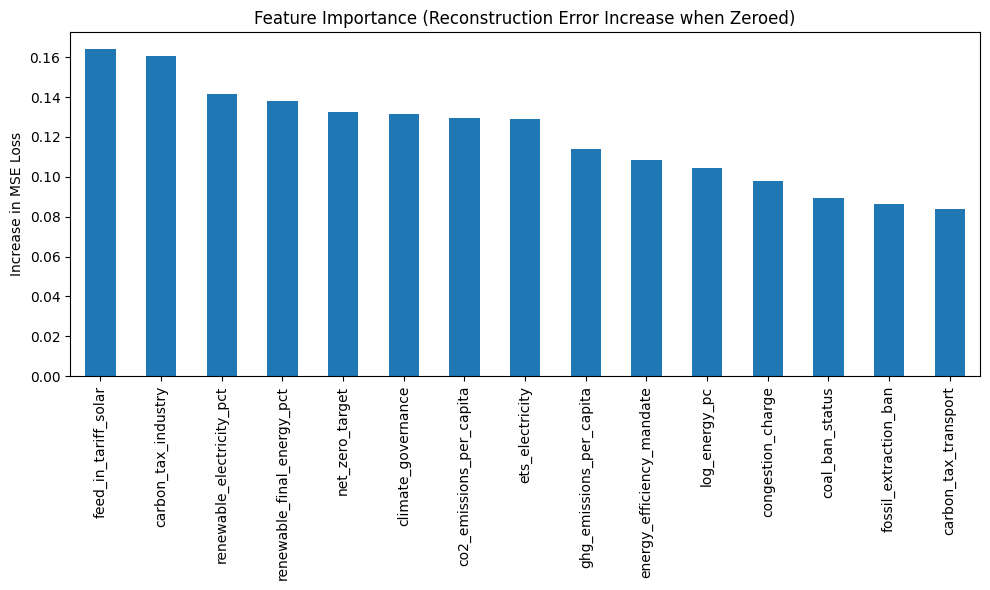

In [77]:
baseline_loss = nn.MSELoss()(model(X_tensor)[1], X_tensor).item()

importance = {}
for i, col in enumerate(X_avg.columns):
    X_perturbed = X_tensor.clone()
    X_perturbed[:, i] = 0
    perturbed_loss = nn.MSELoss()(model(X_perturbed)[1], X_tensor).item()
    importance[col] = perturbed_loss - baseline_loss

importance_df = pd.Series(importance).sort_values(ascending=False)
print("Features that matter most (biggest reconstruction error when zeroed):")
print(importance_df.head(10))

plt.figure(figsize=(10, 6))
importance_df.head(15).plot(kind='bar')
plt.title('Feature Importance (Reconstruction Error Increase when Zeroed)')
plt.ylabel('Increase in MSE Loss')
plt.tight_layout()
plt.savefig('outputs/feature_importance_reconstruction.png', dpi=120, bbox_inches='tight')
plt.show()